Lasso (L1) Test MSE: 0.6164
Ridge (L2) Test MSE: 0.5824

Weight Comparison:
      Feature  Lasso Weights  Ridge Weights
0   Intercept       2.068384       2.068535
1      MedInc       0.742261       0.740145
2    HouseAge       0.141026       0.157865
3    AveRooms       0.001030      -0.084256
4   AveBedrms       0.006874       0.110139
5  Population      -0.000398       0.009209
6    AveOccup      -0.000131      -0.035457
7    Latitude      -0.251679      -0.407444
8   Longitude      -0.209045      -0.369314


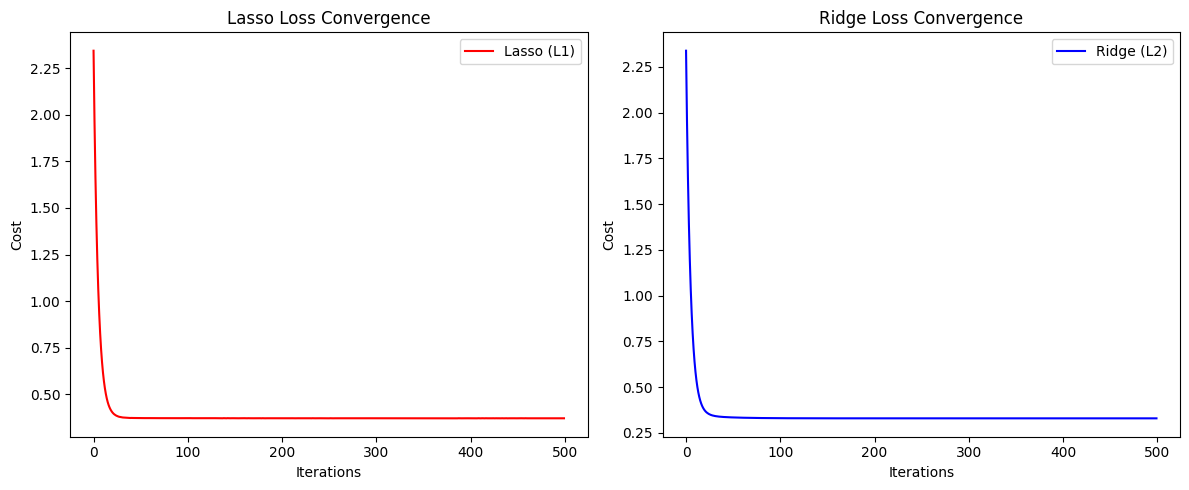

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

class RegularizedLinearRegression:
   def __init__(self, learning_rate=0.01, iterations=1000, l1_penality=0, l2_penality=0):
       self.lr = learning_rate
       self.iterations = iterations
       self.l1_penality = l1_penality
       self.l2_penality = l2_penality
       self.weights = None
       self.loss_history = []

   def compute_cost(self, X, y, weights):
       m = len(y)
       predictions = X.dot(weights)
       base_loss = (1 / (2 * m)) * np.sum(np.square(predictions - y))
      
       # Add L1 and L2 terms (excluding bias weight at index 0)
       l1_term = self.l1_penality * np.sum(np.abs(weights[1:]))
       l2_term = (self.l2_penality / 2) * np.sum(np.square(weights[1:]))
       return base_loss + l1_term + l2_term

   def fit(self, X, y):
       m, n = X.shape
       self.weights = np.zeros(n)
       self.loss_history = []
       for i in range(self.iterations):
           predictions = X.dot(self.weights)
           errors = predictions - y
           gradient = (1 / m) * (X.T.dot(errors))
           l1_grad = self.l1_penality * np.sign(self.weights)
           l2_grad = self.l2_penality * self.weights
           l1_grad[0] = 0
           l2_grad[0] = 0
           self.weights -= self.lr * (gradient + l1_grad + l2_grad)
           self.loss_history.append(self.compute_cost(X, y, self.weights))

   def predict(self, X):
       return X.dot(self.weights)

       
lasso_model = RegularizedLinearRegression(learning_rate=0.1, iterations=500, l1_penality=0.05, l2_penality=0)
lasso_model.fit(X_train, y_train)
ridge_model = RegularizedLinearRegression(learning_rate=0.1, iterations=500, l1_penality=0, l2_penality=0.1)
ridge_model.fit(X_train, y_train)


def get_metrics(model, X, y):
   preds = model.predict(X)
   mse = np.mean((preds - y)**2)
   return mse


print(f"Lasso (L1) Test MSE: {get_metrics(lasso_model, X_test, y_test):.4f}")
print(f"Ridge (L2) Test MSE: {get_metrics(ridge_model, X_test, y_test):.4f}")
weight_df = pd.DataFrame({
   'Feature': ['Intercept'] + data.feature_names,
   'Lasso Weights': lasso_model.weights,
   'Ridge Weights': ridge_model.weights
})
print("\nWeight Comparison:")
print(weight_df)


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(lasso_model.loss_history, color='red', label='Lasso (L1)')
plt.title('Lasso Loss Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(ridge_model.loss_history, color='blue', label='Ridge (L2)')
plt.title('Ridge Loss Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()


plt.tight_layout()
plt.show()

